# Avellaneda-Stoikov Market Making Simulation

## KOSPI200 ATM Option LP Inventory Control Model

Avellaneda-Stoikov(2008) 모델을 기반으로 KOSPI200 Daily ATM 옵션 LP의 잔고관리 시뮬레이션을 구현

### 주요 특징
- **Reservation Price**: 순델타 노출 기반 내부 기준가격
- **Quote Control**: A-S 모델 기반 bid/ask 호가 배치
- **체결 시뮬레이션**: 포아송 프로세스 기반
- **데이터 소스**: 실제 틱 데이터 / Monte Carlo 전환 가능

### 데이터 설계
```
논문에서는 Mid price 가 GBM이었지만, 우리는 데이터가 있으므로 실제 데이터 기반으로 Mid price 산정 Mid Price = (매도호가1 + 매수호가1) / 2 을 1초당 업데이트.
Delta = API 통해서 받아온 데이터의 옵션델타
```

---
## 1. 환경 설정 및 Import

In [121]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import List, Tuple, Optional, Literal
from enum import Enum
import warnings
import os

warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 결과 저장 폴더 생성
RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

---
## 2. 설정 및 파라미터

In [122]:
# === 상수 정의 ===
SECONDS_PER_HOUR = 3600
MIN_PRICE = 0.01
MIN_SPREAD = 0.01


@dataclass
class SimulationConfig:
    """
    시뮬레이션 설정 파라미터
    
    mode:
        - 'paper': 원논문 그대로 재현 (T=1 정규화, GBM, 단순 재고 q)
        - 'develop': KOSPI200 옵션 LP 확장 (실제 데이터, 순델타 q_Δ, tick 적용, 헷지)
    """
    # === 모드 설정 ===
    mode: Literal['paper', 'develop'] = 'develop'
    data_source: Literal['real', 'monte_carlo'] = 'real'
    real_data_path: str = '../data/kospi200_option_B0164812_20260316_1408.csv'
    
    # === Paper 모드 설정 (논문 기준: T=1, dt=0.005, n_steps=200) ===
    paper_n_steps: int = 200
    
    # === Develop 모드: 시간 설정 (실제 장시간: 6시간 = 21600초) ===
    dt: float = 1.0
    T_hours: float = 6.0
    
    # === A-S 모델 파라미터 (논문 기본값) ===
    gamma: float = 0.1      # 위험 회피 계수
    sigma: float = 2.0      # 변동성
    A: float = 140.0        # 체결 강도 기본값
    k: float = 1.5          # 체결 강도 감쇠율
    
    # === Develop 모드: 재고/헷지 설정 ===
    phi: float = 0.05                    # 순델타 페널티 계수
    hedge_threshold: float = 1.0         # 헷지 실행 임계값
    tick_size: float = 0.05              # KRX 호가 단위
    apply_tick_size: bool = True
    
    # === Develop 모드: 스프레드 설정 ===
    spread_multiplier: float = 1.0       # 시장 스프레드 배수
    inventory_spread_coef: float = 0.01  # 재고 기반 스프레드 계수
    use_market_based_spread: bool = True
    
    # === Develop 모드: 체결 설정 ===
    fill_when_inside_market: bool = True
    fill_probability_base: float = 0.5
    
    # === Monte Carlo 설정 ===
    mc_S0: float = 100.0        # 초기 주가
    mc_M0: float = 40.0         # 초기 옵션가
    mc_delta0: float = 0.5      # 초기 델타
    mc_index_vol: float = 0.15  # 지수 변동성
    
    # === 초기 상태 ===
    initial_cash: float = 0.0
    initial_inventory: int = 0
    use_data_length: bool = True
    
    # === 시장 통계 (자동 설정) ===
    market_spread_avg: float = 0.0
    market_spread_std: float = 0.0
    option_mid_avg: float = 0.0
    option_volatility: float = 0.0
    
    def __post_init__(self):
        self._configure_mode_defaults()
    
    def _configure_mode_defaults(self):
        """모드별 기본값 설정"""
        if self.mode == 'paper':
            self.data_source = 'monte_carlo'
            self.apply_tick_size = False
            self.use_market_based_spread = False
        else:
            self.data_source = 'real'
            self.apply_tick_size = True
            self.use_market_based_spread = True
    
    @property
    def T_total(self) -> float:
        """총 시뮬레이션 시간"""
        if self.mode == 'paper':
            return 1.0
        return self.T_hours * SECONDS_PER_HOUR
    
    @property
    def n_steps(self) -> int:
        """총 시뮬레이션 스텝 수"""
        if self.mode == 'paper':
            return self.paper_n_steps
        return int(self.T_hours * SECONDS_PER_HOUR / self.dt)
    
    @property
    def dt_sim(self) -> float:
        """시뮬레이션 dt"""
        if self.mode == 'paper':
            return self.T_total / self.paper_n_steps  # 1/200 = 0.005
        return self.dt

---
## 3. 데이터 로더 (Real / Monte Carlo Switching)

In [123]:
# === 데이터 관련 상수 ===
DEFAULT_BID_ASK_QTY = 10
DELTA_NOISE_STD = 0.02
DELTA_MIN, DELTA_MAX = 0.3, 0.7
OPTION_NOISE_STD = 0.1
TRADING_DAYS_PER_YEAR = 252
HOURS_PER_DAY = 6


@dataclass
class MarketSnapshot:
    """시장 스냅샷 데이터"""
    timestamp: float
    index_price: float
    option_mid: float
    option_delta: float
    best_bid: float
    best_ask: float
    market_spread: float = 0.0
    bid_qty: int = 0
    ask_qty: int = 0
    theoretical_price: float = 0.0
    iv: float = 0.0


class DataLoader:
    """시장 데이터 로더 (Real / Monte Carlo 전환 가능)"""
    
    # 컬럼 매핑
    COLUMN_MAP = {
        'timestamp': '시간',
        'option_mid_ask': '옵션매도호가1',
        'option_mid_bid': '옵션매수호가1',
        'option_delta': '옵션델타',
        'index_price': '지수현재가',
        'bid_qty': '옵션매수잔량1',
        'ask_qty': '옵션매도잔량1',
        'theoretical_price': '옵션이론가',
        'iv': '옵션IV',
    }
    
    def __init__(self, config: SimulationConfig):
        self.config = config
        self.mode = config.mode
        self.data_source = config.data_source
        self.market_stats: dict = {}
        
        if self.data_source == 'real':
            self._load_real_data()
            self._compute_market_statistics()
        else:
            self._setup_monte_carlo()
    
    def _load_real_data(self):
        """실제 데이터 로드 및 전처리"""
        self.df = pd.read_csv(self.config.real_data_path, encoding='utf-8-sig')
        
        # 컬럼 변환
        col = self.COLUMN_MAP
        self.df['timestamp'] = pd.to_datetime(self.df[col['timestamp']])
        self.df['option_mid'] = (self.df[col['option_mid_ask']] + self.df[col['option_mid_bid']]) / 2
        self.df['option_delta'] = self.df[col['option_delta']]
        self.df['index_price'] = self.df[col['index_price']]
        self.df['best_bid'] = self.df[col['option_mid_bid']]
        self.df['best_ask'] = self.df[col['option_mid_ask']]
        self.df['market_spread'] = self.df['best_ask'] - self.df['best_bid']
        self.df['bid_qty'] = self.df[col['bid_qty']]
        self.df['ask_qty'] = self.df[col['ask_qty']]
        self.df['theoretical_price'] = self.df[col['theoretical_price']]
        self.df['iv'] = self.df[col['iv']]
        
        # 결측치 제거
        required_cols = ['option_mid', 'option_delta', 'index_price', 'best_bid', 'best_ask']
        self.df = self.df.dropna(subset=required_cols).reset_index(drop=True)
        self.n_data_points = len(self.df)
    
    def _compute_market_statistics(self):
        """시장 데이터에서 통계 추출"""
        self.config.market_spread_avg = self.df['market_spread'].mean()
        self.config.market_spread_std = self.df['market_spread'].std()
        self.config.option_mid_avg = self.df['option_mid'].mean()
        
        mid_returns = self.df['option_mid'].pct_change().dropna()
        self.config.option_volatility = mid_returns.std()
        
        self.market_stats = {
            'spread_avg': self.config.market_spread_avg,
            'spread_std': self.config.market_spread_std,
            'mid_avg': self.config.option_mid_avg,
            'volatility': self.config.option_volatility,
            'iv_avg': self.df['iv'].mean() if 'iv' in self.df.columns else 0,
            'delta_avg': self.df['option_delta'].mean(),
        }
    
    def _setup_monte_carlo(self):
        """Monte Carlo 시뮬레이션 설정"""
        self.rng = np.random.default_rng(seed=42)
        n_steps = self.config.n_steps
        dt = self.config.dt_sim
        
        if self.mode == 'paper':
            self._setup_paper_mode_paths(n_steps, dt)
        else:
            self._setup_develop_mode_paths(n_steps, dt)
        
        self.n_data_points = n_steps + 1
    
    def _setup_paper_mode_paths(self, n_steps: int, dt: float):
        """Paper 모드용 GBM 경로 생성"""
        sigma = self.config.sigma
        S0 = self.config.mc_S0
        
        dW = self.rng.standard_normal(n_steps) * np.sqrt(dt)
        S_path = S0 + sigma * np.cumsum(dW)
        S_path = np.insert(S_path, 0, S0)
        S_path = np.maximum(S_path, MIN_PRICE)
        
        self.mid_price_path = S_path
        self.delta_path = np.ones(n_steps + 1)
        self.spread = 0.5
    
    def _setup_develop_mode_paths(self, n_steps: int, dt: float):
        """Develop 모드용 Monte Carlo 경로 생성"""
        seconds_per_year = TRADING_DAYS_PER_YEAR * HOURS_PER_DAY * SECONDS_PER_HOUR
        dt_years = dt / seconds_per_year
        
        # 지수 경로
        dW = self.rng.standard_normal(n_steps) * np.sqrt(dt_years)
        log_returns = -0.5 * self.config.mc_index_vol**2 * dt_years + self.config.mc_index_vol * dW
        self.index_path = self.config.mc_S0 * np.exp(np.cumsum(log_returns))
        self.index_path = np.insert(self.index_path, 0, self.config.mc_S0)
        
        # 옵션 가격 경로
        option_noise = self.rng.standard_normal(n_steps + 1) * OPTION_NOISE_STD
        delta = self.config.mc_delta0
        self.mid_price_path = self.config.mc_M0 + delta * (self.index_path - self.config.mc_S0) + option_noise
        self.mid_price_path = np.maximum(self.mid_price_path, MIN_PRICE)
        
        # 델타 경로
        delta_noise = self.rng.standard_normal(n_steps + 1) * DELTA_NOISE_STD
        self.delta_path = np.clip(self.config.mc_delta0 + delta_noise, DELTA_MIN, DELTA_MAX)
        self.spread = 0.25
    
    def get_snapshot(self, step: int) -> MarketSnapshot:
        """특정 스텝의 시장 스냅샷 반환"""
        if self.data_source == 'real':
            return self._get_real_snapshot(step)
        return self._get_monte_carlo_snapshot(step)
    
    def _get_real_snapshot(self, step: int) -> MarketSnapshot:
        """실제 데이터 스냅샷"""
        step = min(step, self.n_data_points - 1)
        row = self.df.iloc[step]
        
        return MarketSnapshot(
            timestamp=step * self.config.dt_sim,
            index_price=float(row['index_price']),
            option_mid=float(row['option_mid']),
            option_delta=float(row['option_delta']),
            best_bid=float(row['best_bid']),
            best_ask=float(row['best_ask']),
            market_spread=float(row['market_spread']),
            bid_qty=int(row['bid_qty']) if pd.notna(row['bid_qty']) else 0,
            ask_qty=int(row['ask_qty']) if pd.notna(row['ask_qty']) else 0,
            theoretical_price=float(row['theoretical_price']) if pd.notna(row['theoretical_price']) else 0.0,
            iv=float(row['iv']) if pd.notna(row['iv']) else 0.0
        )
    
    def _get_monte_carlo_snapshot(self, step: int) -> MarketSnapshot:
        """Monte Carlo 스냅샷"""
        mid_price = self.mid_price_path[step]
        half_spread = self.spread / 2
        index_price = mid_price if self.mode == 'paper' else self.index_path[step]
        
        return MarketSnapshot(
            timestamp=step * self.config.dt_sim,
            index_price=index_price,
            option_mid=mid_price,
            option_delta=self.delta_path[step],
            best_bid=mid_price - half_spread,
            best_ask=mid_price + half_spread,
            market_spread=self.spread,
            bid_qty=DEFAULT_BID_ASK_QTY,
            ask_qty=DEFAULT_BID_ASK_QTY
        )
    
    def get_n_steps(self) -> int:
        """시뮬레이션 스텝 수 반환"""
        if self.data_source == 'real' and self.config.use_data_length:
            return self.n_data_points
        return self.config.n_steps
    
    def get_market_stats(self) -> dict:
        """시장 통계 반환"""
        return self.market_stats

---
## 4. A-S 모델 핵심 로직

In [124]:
# === 체결 확률 관련 상수 ===
FILL_PROBABILITY_BONUS_RATE = 10    # 시장 대비 유리도 보너스 배율
FILL_PROBABILITY_MAX_BONUS = 0.3    # 최대 보너스
FILL_PROBABILITY_MAX = 0.95         # 최대 체결 확률


class AvellanedaStoikovModel:
    """
    Avellaneda-Stoikov Market Making 모델
    
    [paper 모드] 
        - Reservation Price: r = s - q × γ × σ² × (T-t)
        - Spread: δ_a + δ_b = γσ²(T-t) + (2/γ)ln(1 + γ/k)
        - Fill: 포아송 프로세스 λ(δ) = A × e^(-k×δ)
    
    [develop 모드]
        - Reservation Price: r = M - φ × q_Δ × (T-t)/T
        - Spread: 시장 스프레드 기반 + 재고 페널티
        - Fill: 시장 호가 기반 체결
    """
    
    def __init__(self, config: SimulationConfig):
        self.config = config
        self.mode = config.mode
        
        # A-S 모델 파라미터
        self.gamma = config.gamma
        self.sigma = config.sigma
        self.A = config.A
        self.k = config.k
        self.phi = config.phi
        
        # 틱 사이즈 설정
        self.tick_size = config.tick_size
        self.apply_tick_size = config.apply_tick_size
        
        # 스프레드 설정
        self.spread_multiplier = config.spread_multiplier
        self.inventory_spread_coef = config.inventory_spread_coef
        self.use_market_based_spread = config.use_market_based_spread
    
    def _floor_to_tick(self, price: float) -> float:
        """가격을 틱 단위로 내림"""
        return np.floor(price / self.tick_size) * self.tick_size
    
    def _ceil_to_tick(self, price: float) -> float:
        """가격을 틱 단위로 올림"""
        return np.ceil(price / self.tick_size) * self.tick_size
    
    def compute_reservation_price(
        self, mid_price: float, inventory: int, net_delta: float,
        time_remaining: float
    ) -> float:
        """
        Reservation Price 계산
        
        [paper] r = s - q × γ × σ² × (T-t)
        [develop] r = M - φ × q_Δ × (T-t)/T
        """
        if self.mode == 'paper':
            inventory_adjustment = inventory * self.gamma * (self.sigma ** 2) * time_remaining
            return mid_price - inventory_adjustment
        
        delta_adjustment = self.phi * net_delta * time_remaining
        return mid_price - delta_adjustment
    
    def compute_optimal_spread_paper(self, time_remaining: float) -> float:
        """
        [Paper 모드] 최적 스프레드: δ_a + δ_b = γσ²(T-t) + (2/γ)ln(1 + γ/k)
        """
        inventory_term = self.gamma * (self.sigma ** 2) * time_remaining
        intensity_term = (2 / self.gamma) * np.log(1 + self.gamma / self.k)
        return max(inventory_term + intensity_term, MIN_SPREAD)
    
    def compute_optimal_spread_develop(
        self, market_spread: float, net_delta: float
    ) -> float:
        """
        [Develop 모드] 시장 기반 스프레드: spread = market × multiplier + |q_Δ| × coef
        """
        base_spread = market_spread * self.spread_multiplier
        inventory_penalty = abs(net_delta) * self.inventory_spread_coef
        return max(base_spread + inventory_penalty, self.tick_size)
    
    def compute_quotes(
        self, mid_price: float, inventory: int, net_delta: float,
        time_remaining: float, market_spread: float = 0.0
    ) -> Tuple[float, float, float]:
        """호가(bid, ask)와 reservation price 계산"""
        reservation_price = self.compute_reservation_price(
            mid_price, inventory, net_delta, time_remaining
        )
        
        half_spread = self._compute_half_spread(market_spread, net_delta, time_remaining)
        
        bid_raw = reservation_price - half_spread
        ask_raw = reservation_price + half_spread
        
        if self.mode == 'develop' and self.apply_tick_size:
            return self._floor_to_tick(bid_raw), self._ceil_to_tick(ask_raw), reservation_price
        
        return bid_raw, ask_raw, reservation_price
    
    def _compute_half_spread(
        self, market_spread: float, net_delta: float, time_remaining: float
    ) -> float:
        """half spread 계산"""
        if self.mode == 'paper':
            return self.compute_optimal_spread_paper(time_remaining) / 2
        
        if self.use_market_based_spread:
            return self.compute_optimal_spread_develop(market_spread, net_delta) / 2
        
        return self.compute_optimal_spread_paper(time_remaining) / 2
    
    def compute_fill_probability_paper(
        self, price_distance: float, dt: float, T_total: float
    ) -> float:
        """
        [Paper 모드] 포아송 기반 체결 확률
        λ(δ) = A × e^(-k×δ), P(fill) = 1 - e^(-λ×dt/T)
        """
        price_distance = max(price_distance, 0)
        intensity = self.A * np.exp(-self.k * price_distance)
        return 1 - np.exp(-intensity * dt / T_total)
    
    def compute_fill_probability_develop(
        self, lp_price: float, market_price: float, is_bid: bool,
        base_prob: float
    ) -> float:
        """
        [Develop 모드] 시장 호가 기반 체결 확률
        
        - LP bid >= market bid: 체결 가능
        - LP ask <= market ask: 체결 가능
        - 시장 대비 유리할수록 확률 증가
        """
        is_inside_market = self._is_quote_inside_market(lp_price, market_price, is_bid)
        
        if not is_inside_market:
            return 0.0
        
        bonus = self._compute_fill_bonus(lp_price, market_price, is_bid)
        return min(base_prob + bonus, FILL_PROBABILITY_MAX)
    
    def _is_quote_inside_market(
        self, lp_price: float, market_price: float, is_bid: bool
    ) -> bool:
        """LP 호가가 시장 안에 있는지 확인"""
        if is_bid:
            return lp_price >= market_price
        return lp_price <= market_price
    
    def _compute_fill_bonus(
        self, lp_price: float, market_price: float, is_bid: bool
    ) -> float:
        """시장 대비 유리도에 따른 체결 확률 보너스"""
        if is_bid:
            price_advantage = (lp_price - market_price) / market_price
        else:
            price_advantage = (market_price - lp_price) / market_price
        
        return min(price_advantage * FILL_PROBABILITY_BONUS_RATE, FILL_PROBABILITY_MAX_BONUS)

---
## 5. LP Agent 클래스

In [125]:
@dataclass
class LPState:
    """LP 상태"""
    cash: float = 0.0
    inventory: int = 0
    net_delta: float = 0.0
    hedge_position: int = 0
    total_hedges: int = 0
    bid_price: float = 0.0
    ask_price: float = 0.0
    reservation_price: float = 0.0
    total_bought: int = 0
    total_sold: int = 0
    total_trades: int = 0


class LPAgent:
    """LP (Liquidity Provider) Agent"""
    
    def __init__(self, config: SimulationConfig, seed: int = 123):
        self.config = config
        self.mode = config.mode
        self.model = AvellanedaStoikovModel(config)
        self.rng = np.random.default_rng(seed=seed)
        self.state = LPState(cash=config.initial_cash, inventory=config.initial_inventory)
        self.history: List[dict] = []
    
    def update_quotes(self, snapshot: MarketSnapshot, time_remaining: float):
        """호가 업데이트"""
        self._update_net_delta(snapshot)
        
        bid, ask, reservation = self.model.compute_quotes(
            snapshot.option_mid,
            self.state.inventory,
            self.state.net_delta,
            time_remaining,
            market_spread=snapshot.market_spread
        )
        
        self.state.bid_price = bid
        self.state.ask_price = ask
        self.state.reservation_price = reservation
    
    def _update_net_delta(self, snapshot: MarketSnapshot):
        """순델타 업데이트"""
        if self.mode == 'paper':
            self.state.net_delta = float(self.state.inventory)
        else:
            option_delta_exposure = self.state.inventory * snapshot.option_delta
            self.state.net_delta = option_delta_exposure + self.state.hedge_position
    
    def execute_hedge(self, snapshot: MarketSnapshot):
        """헷지 실행 (develop 모드 전용)"""
        if self.mode != 'develop':
            return
        
        threshold = self.config.hedge_threshold
        
        if self.state.net_delta > threshold:
            self.state.hedge_position -= 1
            self.state.total_hedges += 1
        elif self.state.net_delta < -threshold:
            self.state.hedge_position += 1
            self.state.total_hedges += 1
    
    def simulate_fills(
        self, snapshot: MarketSnapshot, dt: float, T_total: float
    ) -> Tuple[bool, bool]:
        """체결 시뮬레이션"""
        prob_bid, prob_ask = self._compute_fill_probabilities(snapshot, dt, T_total)
        
        bid_filled = self.rng.random() < prob_bid
        ask_filled = self.rng.random() < prob_ask
        
        return bid_filled, ask_filled
    
    def _compute_fill_probabilities(
        self, snapshot: MarketSnapshot, dt: float, T_total: float
    ) -> Tuple[float, float]:
        """체결 확률 계산"""
        if self.mode == 'paper':
            delta_bid = snapshot.option_mid - self.state.bid_price
            delta_ask = self.state.ask_price - snapshot.option_mid
            
            prob_bid = self.model.compute_fill_probability_paper(delta_bid, dt, T_total)
            prob_ask = self.model.compute_fill_probability_paper(delta_ask, dt, T_total)
        else:
            prob_bid = self.model.compute_fill_probability_develop(
                self.state.bid_price,
                snapshot.best_bid,
                is_bid=True,
                base_prob=self.config.fill_probability_base
            )
            prob_ask = self.model.compute_fill_probability_develop(
                self.state.ask_price,
                snapshot.best_ask,
                is_bid=False,
                base_prob=self.config.fill_probability_base
            )
        
        return prob_bid, prob_ask
    
    def execute_fills(self, bid_filled: bool, ask_filled: bool):
        """체결 실행"""
        if bid_filled:
            self._execute_buy()
        if ask_filled:
            self._execute_sell()
    
    def _execute_buy(self):
        """매수 체결"""
        self.state.inventory += 1
        self.state.cash -= self.state.bid_price
        self.state.total_bought += 1
        self.state.total_trades += 1
    
    def _execute_sell(self):
        """매도 체결"""
        self.state.inventory -= 1
        self.state.cash += self.state.ask_price
        self.state.total_sold += 1
        self.state.total_trades += 1
    
    def compute_pnl(self, current_mid: float) -> float:
        """P&L 계산: cash + inventory × mid_price"""
        return self.state.cash + self.state.inventory * current_mid
    
    def record_state(self, step: int, snapshot: MarketSnapshot, time_remaining: float):
        """상태 기록"""
        record = self._build_base_record(step, snapshot, time_remaining)
        
        if self.mode == 'develop':
            record.update(self._build_develop_record(snapshot))
        
        self.history.append(record)
    
    def _build_base_record(
        self, step: int, snapshot: MarketSnapshot, time_remaining: float
    ) -> dict:
        """기본 상태 기록"""
        return {
            'step': step,
            'timestamp': snapshot.timestamp,
            'index_price': snapshot.index_price,
            'option_mid': snapshot.option_mid,
            'option_delta': snapshot.option_delta,
            'market_bid': snapshot.best_bid,
            'market_ask': snapshot.best_ask,
            'market_spread': snapshot.market_spread,
            'cash': self.state.cash,
            'inventory': self.state.inventory,
            'net_delta': self.state.net_delta,
            'reservation_price': self.state.reservation_price,
            'lp_bid': self.state.bid_price,
            'lp_ask': self.state.ask_price,
            'lp_spread': self.state.ask_price - self.state.bid_price,
            'pnl': self.compute_pnl(snapshot.option_mid),
            'time_remaining': time_remaining,
            'total_trades': self.state.total_trades,
            'total_bought': self.state.total_bought,
            'total_sold': self.state.total_sold,
        }
    
    def _build_develop_record(self, snapshot: MarketSnapshot) -> dict:
        """Develop 모드 추가 기록"""
        return {
            'hedge_position': self.state.hedge_position,
            'total_hedges': self.state.total_hedges,
            'bid_inside_market': self.state.bid_price >= snapshot.best_bid,
            'ask_inside_market': self.state.ask_price <= snapshot.best_ask,
        }
    
    def get_history_df(self) -> pd.DataFrame:
        """히스토리 DataFrame 반환"""
        return pd.DataFrame(self.history)

---
## 6. 시뮬레이션 엔진

In [126]:
class Simulator:
    """A-S Market Making 시뮬레이션 엔진"""
    
    def __init__(self, config: SimulationConfig, seed: int = 123):
        self.config = config
        self.mode = config.mode
        self.loader = DataLoader(config)
        self.agent = LPAgent(config, seed=seed)
    
    def run(self, verbose: bool = True) -> pd.DataFrame:
        """시뮬레이션 실행"""
        n_steps = self.loader.get_n_steps()
        dt = self.config.dt_sim
        T_total = self.config.T_total
        
        for step in range(n_steps):
            self._run_step(step, dt, T_total)
        
        return self.agent.get_history_df()
    
    def _run_step(self, step: int, dt: float, T_total: float):
        """단일 스텝 실행"""
        current_time = step * dt
        time_remaining = self._compute_time_remaining(current_time, T_total)
        
        snapshot = self.loader.get_snapshot(step)
        
        # 호가 업데이트 → 체결 시뮬레이션 → 체결 실행
        self.agent.update_quotes(snapshot, time_remaining)
        bid_filled, ask_filled = self.agent.simulate_fills(snapshot, dt, T_total)
        self.agent.execute_fills(bid_filled, ask_filled)
        
        # Develop 모드: 헷지 실행
        if self.mode == 'develop':
            self.agent.execute_hedge(snapshot)
        
        self.agent.record_state(step, snapshot, time_remaining)
    
    def _compute_time_remaining(self, current_time: float, T_total: float) -> float:
        """남은 시간 계산 (정규화: 1 → 0)"""
        # 두 모드 모두 동일: (T-t)/T 형태로 1→0 반환
        return (T_total - current_time) / T_total

---
## 7. 시뮬레이션 실행 (실제 데이터)

In [127]:
# ================================================================
# 모드 선택
# ================================================================
#MODE = 'develop'  # KOSPI200 옵션 LP 확장 #여기!
MODE = 'paper'      # 원논문 재현 (T=1 정규화)

# ================================================================
# 시뮬레이션 설정
# ================================================================
if MODE == 'paper':
    config = SimulationConfig(
        mode='paper',
        paper_n_steps=21600,
        gamma=0.1, sigma=2.0, A=140.0, k=1.5,
        mc_S0=100.0
    )
else:
    config = SimulationConfig(
        mode='develop',
        real_data_path='../data/kospi200_option_B0164812_20260316_1408.csv',
        use_data_length=True,
        # A-S 기본 파라미터 (paper 모드와 호환)
        gamma=0.1, sigma=2.0, A=140.0, k=1.5,
        # develop 모드 전용 파라미터
        phi=0.05,
        hedge_threshold=1.0,
        tick_size=0.05,
        # 시장 기반 스프레드 설정
        spread_multiplier=1.0,        # 시장 스프레드와 동일
        inventory_spread_coef=0.01,   # 재고 페널티
        use_market_based_spread=True,
        # 체결 확률 설정
        fill_probability_base=0.02,   # 기본 체결 확률 (스텝당)
    )

# ================================================================
# 시뮬레이션 실행
# ================================================================
simulator = Simulator(config, seed=42)
results = simulator.run(verbose=False)

# 시장 통계 출력 (develop 모드)
if MODE == 'develop':
    stats = simulator.loader.get_market_stats()
    print("=== 시장 데이터 통계 ===")
    print(f"시장 스프레드 평균: {stats['spread_avg']:.4f}")
    print(f"옵션 Mid 평균: {stats['mid_avg']:.2f}")
    print(f"옵션 IV 평균: {stats['iv_avg']:.2f}%")
    print(f"옵션 델타 평균: {stats['delta_avg']:.4f}")

In [128]:
# 결과 요약
final = results.iloc[-1]

summary = {
    'P&L': final['pnl'],
    'Inventory': final['inventory'],
    'Net Delta': final['net_delta'],
    'Cash': final['cash'],
    'Total Trades': final['total_trades'],
    'Bought': final['total_bought'],
    'Sold': final['total_sold']
}

if MODE == 'develop':
    summary['Hedge Position'] = final['hedge_position']
    summary['Total Hedges'] = final['total_hedges']
    # 체결 분석
    bid_inside_pct = results['bid_inside_market'].mean() * 100
    ask_inside_pct = results['ask_inside_market'].mean() * 100
    print(f"\n=== 체결 분석 ===")
    print(f"LP Bid가 시장 안에 있는 비율: {bid_inside_pct:.1f}%")
    print(f"LP Ask가 시장 안에 있는 비율: {ask_inside_pct:.1f}%")
    print(f"LP 스프레드 평균: {results['lp_spread'].mean():.4f}")
    print(f"시장 스프레드 평균: {results['market_spread'].mean():.4f}")

print("\n=== 시뮬레이션 결과 ===")
pd.Series(summary).to_frame('Value')


=== 시뮬레이션 결과 ===


,Value
P&L,70.695411
Inventory,0.000000
Net Delta,0.000000
Cash,70.695411
Total Trades,108.000000
Bought,54.000000
Sold,54.000000


---
## 8. 결과 시각화

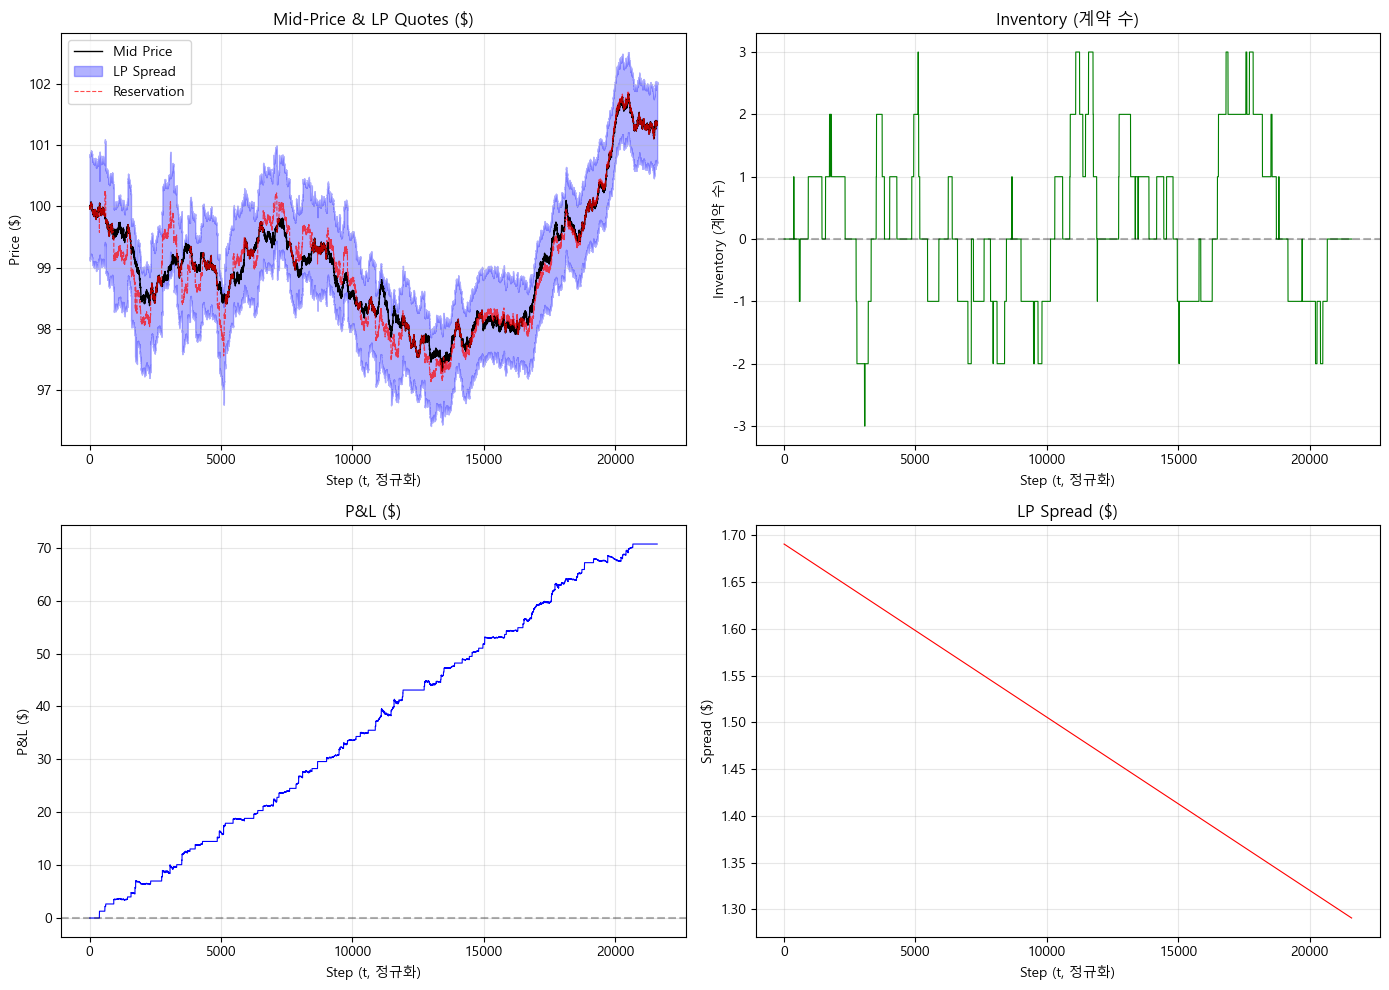

In [129]:
# 모드별 시각화
x = results['step']

if MODE == 'paper':
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 단위 설정 (paper 모드: 정규화 시간, 가격 단위)
    time_unit = '(t, 정규화)'
    price_unit = '($)'
    
    axes[0, 0].plot(x, results['option_mid'], 'k-', label='Mid Price', linewidth=1)
    axes[0, 0].fill_between(x, results['lp_bid'], results['lp_ask'], alpha=0.3, color='blue', label='LP Spread')
    axes[0, 0].plot(x, results['reservation_price'], 'r--', label='Reservation', linewidth=0.8, alpha=0.7)
    axes[0, 0].set_xlabel(f'Step {time_unit}')
    axes[0, 0].set_ylabel(f'Price {price_unit}')
    axes[0, 0].set_title(f'Mid-Price & LP Quotes {price_unit}')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    axes[0, 1].plot(x, results['inventory'], 'g-', linewidth=0.8)
    axes[0, 1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
    axes[0, 1].set_xlabel(f'Step {time_unit}')
    axes[0, 1].set_ylabel('Inventory (계약 수)')
    axes[0, 1].set_title('Inventory (계약 수)')
    axes[0, 1].grid(True, alpha=0.3)
    
    axes[1, 0].plot(x, results['pnl'], 'b-', linewidth=0.8)
    axes[1, 0].axhline(y=0, color='k', linestyle='--', alpha=0.3)
    axes[1, 0].set_xlabel(f'Step {time_unit}')
    axes[1, 0].set_ylabel(f'P&L {price_unit}')
    axes[1, 0].set_title(f'P&L {price_unit}')
    axes[1, 0].grid(True, alpha=0.3)
    
    axes[1, 1].plot(x, results['lp_spread'], 'r-', linewidth=0.8)
    axes[1, 1].set_xlabel(f'Step {time_unit}')
    axes[1, 1].set_ylabel(f'Spread {price_unit}')
    axes[1, 1].set_title(f'LP Spread {price_unit}')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/simulation_results_paper_mode.png', dpi=150, bbox_inches='tight')
    
else:
    fig, axes = plt.subplots(3, 2, figsize=(14, 12))
    
    # 단위 설정 (develop 모드: 초, 포인트)
    time_unit = '(초)'
    price_unit = '(pt)'
    
    axes[0, 0].plot(x, results['pnl'], 'b-', linewidth=0.8)
    axes[0, 0].axhline(y=0, color='k', linestyle='--', alpha=0.3)
    axes[0, 0].set_xlabel(f'Step {time_unit}')
    axes[0, 0].set_ylabel(f'P&L {price_unit}')
    axes[0, 0].set_title(f'P&L {price_unit}')
    axes[0, 0].grid(True, alpha=0.3)
    
    axes[0, 1].plot(x, results['inventory'], 'g-', linewidth=0.8)
    axes[0, 1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
    axes[0, 1].set_xlabel(f'Step {time_unit}')
    axes[0, 1].set_ylabel('Inventory (계약 수)')
    axes[0, 1].set_title('Inventory (계약 수)')
    axes[0, 1].grid(True, alpha=0.3)
    
    theta = config.hedge_threshold
    axes[1, 0].plot(x, results['net_delta'], 'r-', linewidth=0.8)
    axes[1, 0].axhline(y=theta, color='orange', linestyle=':', alpha=0.7)
    axes[1, 0].axhline(y=-theta, color='orange', linestyle=':', alpha=0.7)
    axes[1, 0].fill_between(x, -theta, theta, alpha=0.1, color='green')
    axes[1, 0].set_xlabel(f'Step {time_unit}')
    axes[1, 0].set_ylabel('Net Delta (Δ)')
    axes[1, 0].set_title(f'Net Delta (θ={theta})')
    axes[1, 0].grid(True, alpha=0.3)
    
    axes[1, 1].plot(x, results['hedge_position'], 'purple', linewidth=0.8)
    axes[1, 1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
    axes[1, 1].set_xlabel(f'Step {time_unit}')
    axes[1, 1].set_ylabel('Hedge Position (계약 수)')
    axes[1, 1].set_title(f'Hedge Position (총 {results["total_hedges"].iloc[-1]}회)')
    axes[1, 1].grid(True, alpha=0.3)
    
    axes[2, 0].plot(x, results['option_mid'], 'k-', label='Mid', linewidth=1)
    axes[2, 0].fill_between(x, results['lp_bid'], results['lp_ask'], alpha=0.2, color='green', label='LP Spread')
    axes[2, 0].set_xlabel(f'Step {time_unit}')
    axes[2, 0].set_ylabel(f'Price {price_unit}')
    axes[2, 0].set_title(f'Option Price & LP Quotes {price_unit}')
    axes[2, 0].legend()
    axes[2, 0].grid(True, alpha=0.3)
    
    axes[2, 1].plot(x, results['market_spread'], 'b-', label='Market', alpha=0.7, linewidth=0.8)
    axes[2, 1].plot(x, results['lp_spread'], 'r-', label='LP', alpha=0.7, linewidth=0.8)
    axes[2, 1].set_xlabel(f'Step {time_unit}')
    axes[2, 1].set_ylabel(f'Spread {price_unit}')
    axes[2, 1].set_title(f'Spread Comparison {price_unit}')
    axes[2, 1].legend()
    axes[2, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/simulation_results_develop_mode.png', dpi=150, bbox_inches='tight')

plt.show()

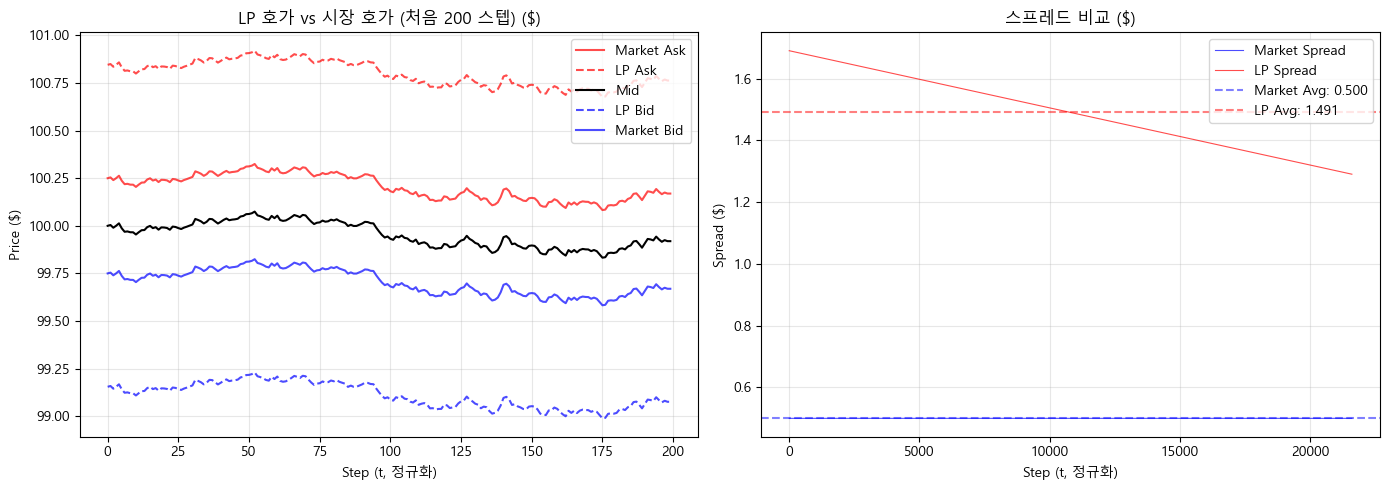

In [130]:
# LP 호가 vs 시장 호가 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 단위 설정
if MODE == 'paper':
    price_unit = '($)'
    time_unit = '(t, 정규화)'
else:
    price_unit = '(pt)'
    time_unit = '(초)'

# 1. LP 호가 vs 시장 호가 (일부 구간 확대)
ax1 = axes[0]
sample_range = slice(0, min(200, len(results)))  # 처음 200개 스텝
x_sample = results['step'].iloc[sample_range]

ax1.plot(x_sample, results['market_ask'].iloc[sample_range], 'r-', label='Market Ask', alpha=0.7)
ax1.plot(x_sample, results['lp_ask'].iloc[sample_range], 'r--', label='LP Ask', alpha=0.7)
ax1.plot(x_sample, results['option_mid'].iloc[sample_range], 'k-', label='Mid', linewidth=1.5)
ax1.plot(x_sample, results['lp_bid'].iloc[sample_range], 'b--', label='LP Bid', alpha=0.7)
ax1.plot(x_sample, results['market_bid'].iloc[sample_range], 'b-', label='Market Bid', alpha=0.7)

ax1.set_xlabel(f'Step {time_unit}')
ax1.set_ylabel(f'Price {price_unit}')
ax1.set_title(f'LP 호가 vs 시장 호가 (처음 200 스텝) {price_unit}')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# 2. 스프레드 비교
ax2 = axes[1]
ax2.plot(x, results['market_spread'], 'b-', label='Market Spread', alpha=0.7, linewidth=0.8)
ax2.plot(x, results['lp_spread'], 'r-', label='LP Spread', alpha=0.7, linewidth=0.8)
ax2.axhline(y=results['market_spread'].mean(), color='b', linestyle='--', alpha=0.5, 
            label=f'Market Avg: {results["market_spread"].mean():.3f}')
ax2.axhline(y=results['lp_spread'].mean(), color='r', linestyle='--', alpha=0.5,
            label=f'LP Avg: {results["lp_spread"].mean():.3f}')
ax2.set_xlabel(f'Step {time_unit}')
ax2.set_ylabel(f'Spread {price_unit}')
ax2.set_title(f'스프레드 비교 {price_unit}')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/spread_comparison_{MODE}_mode.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. 여러 번 시뮬레이션 (다른 시드)

In [131]:
# 여러 번 시뮬레이션
n_simulations = 50
final_pnls, final_inventories, final_trades = [], [], []

for i in range(n_simulations):
    sim = Simulator(config, seed=i)
    res = sim.run(verbose=False)
    final_pnls.append(res['pnl'].iloc[-1])
    final_inventories.append(res['inventory'].iloc[-1])
    final_trades.append(res['total_trades'].iloc[-1])

final_pnls = np.array(final_pnls)
final_inventories = np.array(final_inventories)
final_trades = np.array(final_trades)

pd.DataFrame({
    'P&L': [final_pnls.mean(), final_pnls.std()],
    'Inventory': [final_inventories.mean(), final_inventories.std()],
    'Trades': [final_trades.mean(), final_trades.std()]
}, index=['Mean', 'Std'])

,P&L,Inventory,Trades
Mean,63.611507,-0.280000,98.240000
Std,8.215176,3.268272,9.349995


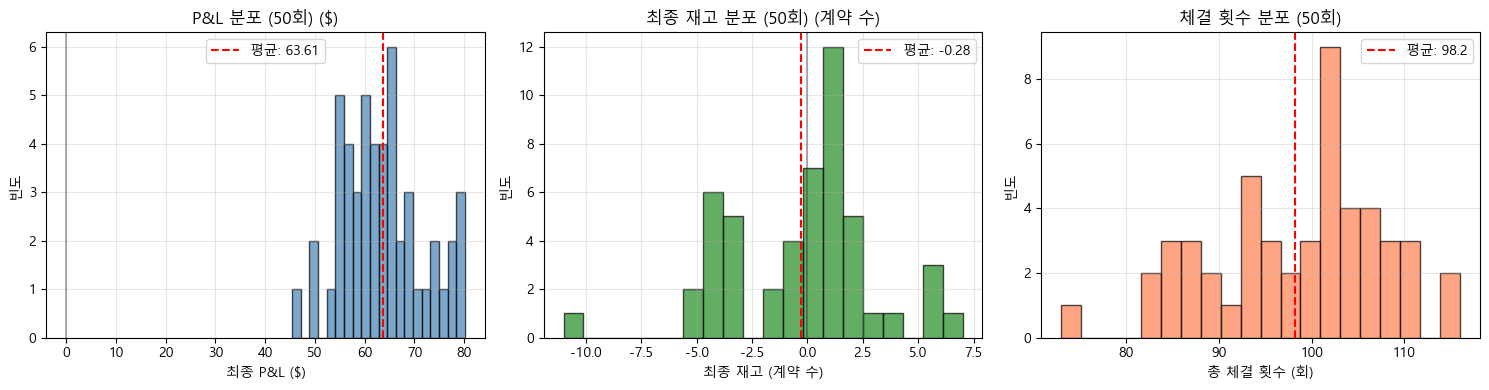

In [132]:
# 분포 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 단위 설정
if MODE == 'paper':
    price_unit = '($)'
else:
    price_unit = '(pt)'

# P&L 분포
ax1 = axes[0]
ax1.hist(final_pnls, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(x=final_pnls.mean(), color='red', linestyle='--', 
            label=f'평균: {final_pnls.mean():.2f}')
ax1.axvline(x=0, color='black', linestyle='-', alpha=0.3)
ax1.set_xlabel(f'최종 P&L {price_unit}')
ax1.set_ylabel('빈도')
ax1.set_title(f'P&L 분포 ({n_simulations}회) {price_unit}')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 재고 분포
ax2 = axes[1]
ax2.hist(final_inventories, bins=20, edgecolor='black', alpha=0.7, color='forestgreen')
ax2.axvline(x=final_inventories.mean(), color='red', linestyle='--',
            label=f'평균: {final_inventories.mean():.2f}')
ax2.axvline(x=0, color='black', linestyle='-', alpha=0.3)
ax2.set_xlabel('최종 재고 (계약 수)')
ax2.set_ylabel('빈도')
ax2.set_title(f'최종 재고 분포 ({n_simulations}회) (계약 수)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 체결 횟수 분포
ax3 = axes[2]
ax3.hist(final_trades, bins=20, edgecolor='black', alpha=0.7, color='coral')
ax3.axvline(x=final_trades.mean(), color='red', linestyle='--',
            label=f'평균: {final_trades.mean():.1f}')
ax3.set_xlabel('총 체결 횟수 (회)')
ax3.set_ylabel('빈도')
ax3.set_title(f'체결 횟수 분포 ({n_simulations}회)')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/simulation_distribution_{MODE}_mode.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. 파라미터 민감도 분석

In [133]:
# γ 민감도 분석
gammas = [0.01, 0.05, 0.1, 0.5, 1.0]
gamma_results = {}

for gamma in gammas:
    config_test = SimulationConfig(
        mode='develop',
        real_data_path='../data/kospi200_option_B0164812_20260316_1408.csv',
        use_data_length=True, gamma=gamma, sigma=2.0, A=140.0, k=1.5, phi=0.05
    )
    res = Simulator(config_test, seed=42).run(verbose=False)
    gamma_results[gamma] = {
        'pnl_final': res['pnl'].iloc[-1],
        'inventory_std': res['inventory'].std(),
        'lp_spread_avg': res['lp_spread'].mean(),
        'trades': res['total_trades'].iloc[-1]
    }

pd.DataFrame(gamma_results).T

,pnl_final,inventory_std,lp_spread_avg,trades
0.01,52.4,0.662834,0.316383,384.0
0.05,52.4,0.662834,0.316383,384.0
0.10,52.4,0.662834,0.316383,384.0
0.50,52.4,0.662834,0.316383,384.0
1.00,52.4,0.662834,0.316383,384.0


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

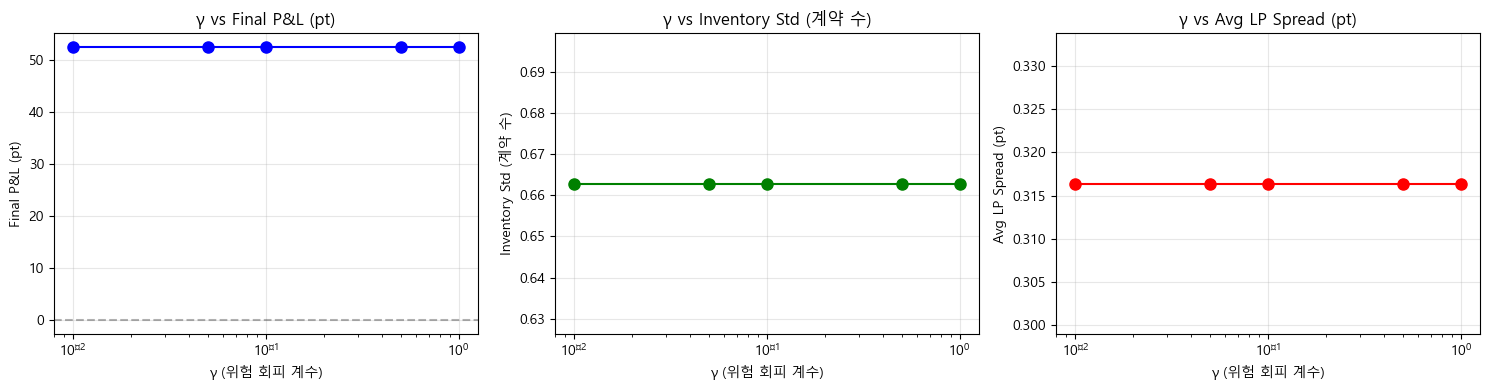

In [134]:
# 민감도 분석 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
gammas_list = list(gamma_results.keys())

# 단위 설정 (γ 민감도 분석은 항상 develop 모드에서 실행)
price_unit = '(pt)'

axes[0].plot(gammas_list, [gamma_results[g]['pnl_final'] for g in gammas_list], 'bo-', markersize=8)
axes[0].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[0].set_xlabel('γ (위험 회피 계수)')
axes[0].set_ylabel(f'Final P&L {price_unit}')
axes[0].set_title(f'γ vs Final P&L {price_unit}')
axes[0].set_xscale('log')
axes[0].grid(True, alpha=0.3)

axes[1].plot(gammas_list, [gamma_results[g]['inventory_std'] for g in gammas_list], 'go-', markersize=8)
axes[1].set_xlabel('γ (위험 회피 계수)')
axes[1].set_ylabel('Inventory Std (계약 수)')
axes[1].set_title('γ vs Inventory Std (계약 수)')
axes[1].set_xscale('log')
axes[1].grid(True, alpha=0.3)

axes[2].plot(gammas_list, [gamma_results[g]['lp_spread_avg'] for g in gammas_list], 'ro-', markersize=8)
axes[2].set_xlabel('γ (위험 회피 계수)')
axes[2].set_ylabel(f'Avg LP Spread {price_unit}')
axes[2].set_title(f'γ vs Avg LP Spread {price_unit}')
axes[2].set_xscale('log')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/gamma_sensitivity_{MODE}_mode.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11. 결과 데이터 저장

In [135]:
# 결과 저장
results.to_csv(f'{RESULTS_DIR}/simulation_results_{MODE}_mode.csv', index=False, encoding='utf-8-sig')
results.head(10)

,step,timestamp,index_price,option_mid,option_delta,market_bid,market_ask,market_spread,cash,inventory,net_delta,reservation_price,lp_bid,lp_ask,lp_spread,pnl,time_remaining,total_trades,total_bought,total_sold
0,0,0.000000,100.000000,100.000000,1.0,99.750000,100.250000,0.5,0.0,0,0.0,100.000000,99.154615,100.845385,1.690770,0.0,1.000000,0,0,0
1,1,0.000046,100.004147,100.004147,1.0,99.754147,100.254147,0.5,0.0,0,0.0,100.004147,99.158771,100.849523,1.690752,0.0,0.999954,0,0,0
2,2,0.000093,99.989994,99.989994,1.0,99.739994,100.239994,0.5,0.0,0,0.0,99.989994,99.144628,100.835361,1.690733,0.0,0.999907,0,0,0
3,3,0.000139,100.000207,100.000207,1.0,99.750207,100.250207,0.5,0.0,0,0.0,100.000207,99.154849,100.845564,1.690715,0.0,0.999861,0,0,0
4,4,0.000185,100.013006,100.013006,1.0,99.763006,100.263006,0.5,0.0,0,0.0,100.013006,99.167658,100.858354,1.690696,0.0,0.999815,0,0,0
5,5,0.000231,99.986456,99.986456,1.0,99.736456,100.236456,0.5,0.0,0,0.0,99.986456,99.141117,100.831795,1.690678,0.0,0.999769,0,0,0
6,6,0.000278,99.968735,99.968735,1.0,99.718735,100.218735,0.5,0.0,0,0.0,99.968735,99.123406,100.814065,1.690659,0.0,0.999722,0,0,0
7,7,0.000324,99.970475,99.970475,1.0,99.720475,100.220475,0.5,0.0,0,0.0,99.970475,99.125155,100.815796,1.690641,0.0,0.999676,0,0,0
8,8,0.000370,99.966172,99.966172,1.0,99.716172,100.216172,0.5,0.0,0,0.0,99.966172,99.120860,100.811483,1.690622,0.0,0.999630,0,0,0
9,9,0.000417,99.965943,99.965943,1.0,99.715943,100.215943,0.5,0.0,0,0.0,99.965943,99.120641,100.811245,1.690604,0.0,0.999583,0,0,0
